In [1]:
# 导入必要的库
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms



In [2]:
# 设置设备
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用设备: {device}")  # 打印当前使用的设备信息

使用设备: cpu


In [3]:
# 数据预处理和加载
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # MNIST 标准化参数
])

# 加载 MNIST 数据集,使用 transforms 进行数据预处理和标准化
train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST('./data', train=False, download=True, transform=transform)

# 创建数据加载器
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)


In [4]:
# 建立全连接神经网络模型
model = nn.Sequential(
    nn.Flatten(),  # 将 28x28 图像展平为 784 维向量
    nn.Linear(784, 128),  # 全连接层，128 个神经元
    nn.ReLU(),  # ReLU 激活函数
    nn.Linear(128, 10)  # 输出层，10 个神经元
).to(device)


In [5]:
# 配置训练方法：优化器、损失函数
optimizer = optim.Adam(model.parameters())
criterion = nn.CrossEntropyLoss()


In [6]:
# 训练模型
model.train()
for epoch in range(5):
    for data, target in train_loader:
        data, target = data.to(device), target.to(device)
        
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
    
    print(f'Epoch {epoch+1} completed')



Epoch 1 completed
Epoch 2 completed
Epoch 3 completed
Epoch 4 completed
Epoch 5 completed


In [7]:
# 模型评估
model.eval()
test_loss = 0
correct = 0
total = 0

with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output = model(data)
        test_loss += criterion(output, target).item()
        pred = output.argmax(dim=1, keepdim=True)
        correct += pred.eq(target.view_as(pred)).sum().item()
        total += target.size(0)

test_loss /= len(test_loader)
accuracy = 100. * correct / total

print(f'Test set: Average loss: {test_loss:.4f}, Accuracy: {correct}/{total} ({accuracy:.2f}%)')


Test set: Average loss: 0.0756, Accuracy: 9761/10000 (97.61%)


In [8]:
import time
import pandas as pd
import matplotlib.pyplot as plt

EXPERIMENT_EPOCHS = 3
BASE_LR = 1e-3
MAX_TRAIN_BATCHES = None
MAX_TEST_BATCHES = None  # Set to an int for quick runs

def get_loaders(batch_size):
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    return train_loader, test_loader

def activation_from_name(name):
    name = name.lower()
    if name == "relu":
        return nn.ReLU
    if name == "tanh":
        return nn.Tanh
    if name == "sigmoid":
        return nn.Sigmoid
    if name == "leakyrelu":
        return nn.LeakyReLU
    raise ValueError(f"Unsupported activation: {name}")

def build_mnist_mlp(hidden_size=128, depth=3, activation="relu"):
    act = activation_from_name(activation)
    layers = [nn.Flatten(), nn.Linear(784, hidden_size), act()]
    for _ in range(depth - 1):
        layers.extend([nn.Linear(hidden_size, hidden_size), act()])
    layers.append(nn.Linear(hidden_size, 10))
    return nn.Sequential(*layers).to(device)

def train_eval_mnist(config, epochs=EXPERIMENT_EPOCHS, lr=BASE_LR):
    train_loader, test_loader = get_loaders(config["batch_size"])
    model = build_mnist_mlp(
        hidden_size=config["hidden_size"],
        depth=config["depth"],
        activation=config["activation"],
    )
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    history = {"train_loss": [], "test_loss": [], "test_acc": []}
    total_train_seen = 0
    start = time.perf_counter()

    for _ in range(epochs):
        model.train()
        running_loss = 0.0
        seen = 0
        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = data.to(device), target.to(device)

            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()

            batch_size = data.size(0)
            running_loss += loss.item() * batch_size
            seen += batch_size

            if MAX_TRAIN_BATCHES is not None and (batch_idx + 1) >= MAX_TRAIN_BATCHES:
                break

        train_loss = running_loss / max(seen, 1)
        total_train_seen += seen

        model.eval()
        test_running = 0.0
        correct = 0
        test_seen = 0
        with torch.no_grad():
            for batch_idx, (data, target) in enumerate(test_loader):
                data, target = data.to(device), target.to(device)
                output = model(data)
                loss = criterion(output, target)

                batch_size = data.size(0)
                test_running += loss.item() * batch_size
                pred = output.argmax(dim=1, keepdim=True)
                correct += pred.eq(target.view_as(pred)).sum().item()
                test_seen += batch_size

                if MAX_TEST_BATCHES is not None and (batch_idx + 1) >= MAX_TEST_BATCHES:
                    break

        test_loss = test_running / max(test_seen, 1)
        test_acc = 100.0 * correct / max(test_seen, 1)

        history["train_loss"].append(train_loss)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)

    elapsed = time.perf_counter() - start
    samples_per_sec = total_train_seen / max(elapsed, 1e-9)

    metrics = {
        "batch_size": config["batch_size"],
        "depth": config["depth"],
        "hidden_size": config["hidden_size"],
        "activation": config["activation"],
        "final_train_loss": history["train_loss"][-1],
        "final_test_loss": history["test_loss"][-1],
        "test_acc": history["test_acc"][-1],
        "train_time_sec": elapsed,
        "samples_per_sec": samples_per_sec,
    }
    return metrics, history

def run_sweep(param_name, values, base_config):
    results = []
    histories = {}
    for value in values:
        config = dict(base_config)
        config[param_name] = value
        metrics, history = train_eval_mnist(config)
        results.append(metrics)
        histories[value] = history
    return pd.DataFrame(results), histories

def plot_loss_curves(histories, title):
    plt.figure(figsize=(7, 4))
    for key, history in histories.items():
        plt.plot(history["train_loss"], label=str(key))
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Train loss")
    plt.legend()
    plt.tight_layout()

def plot_metric(df, x_col, y_col, title):
    plt.figure(figsize=(6, 4))
    plt.plot(df[x_col], df[y_col], marker="o")
    plt.title(title)
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

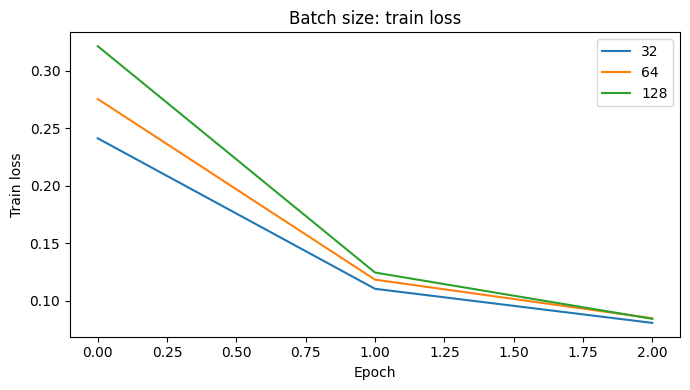

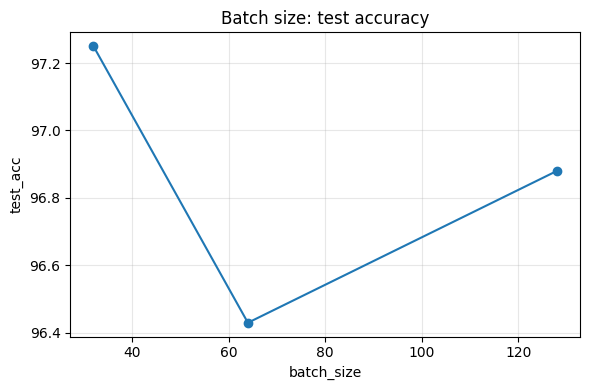

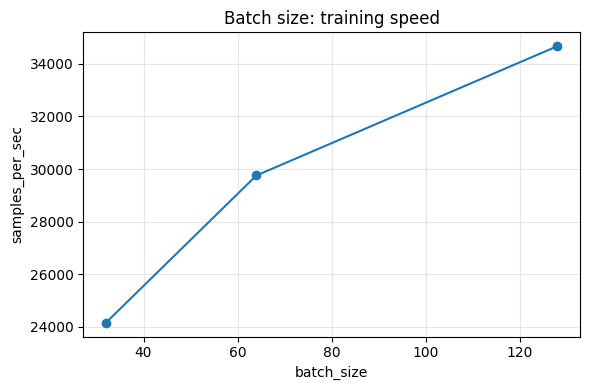

In [9]:
base_config = {
    "batch_size": 64,
    "depth": 3,
    "hidden_size": 128,
    "activation": "relu",
}

batch_sizes = [32, 64, 128]
batch_df, batch_histories = run_sweep("batch_size", batch_sizes, base_config)
batch_df = batch_df.sort_values("batch_size")
batch_df

plot_loss_curves(batch_histories, "Batch size: train loss")
plot_metric(batch_df, "batch_size", "test_acc", "Batch size: test accuracy")
plot_metric(batch_df, "batch_size", "samples_per_sec", "Batch size: training speed")

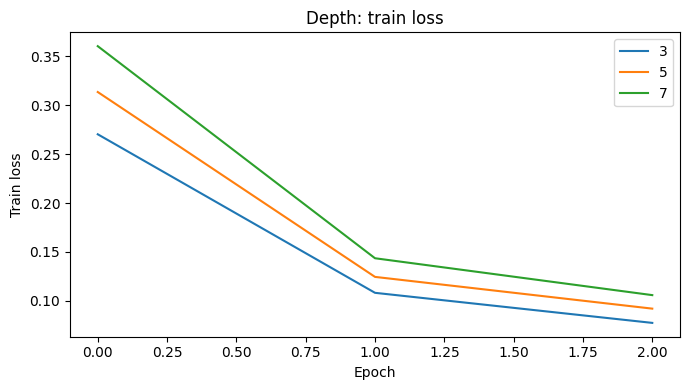

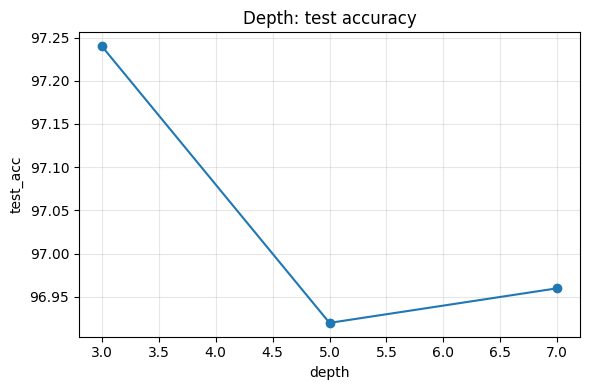

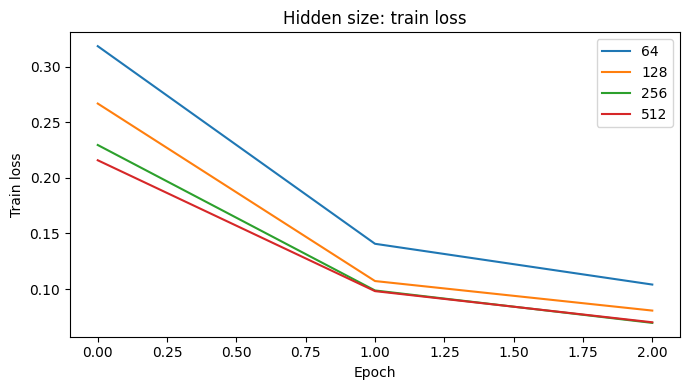

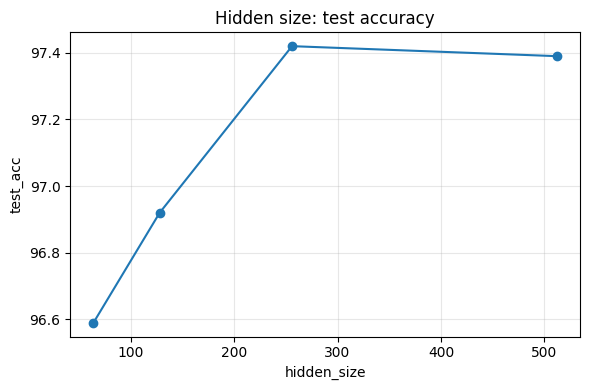

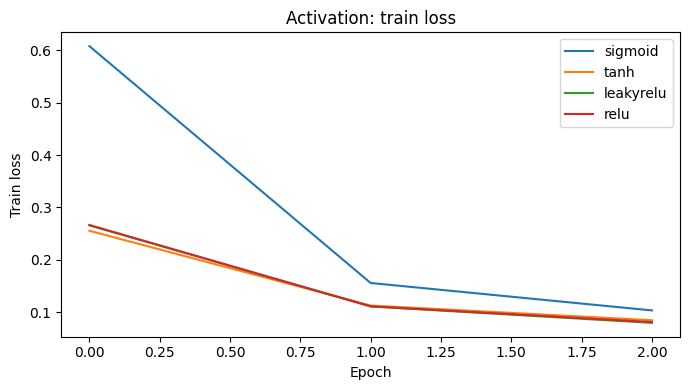

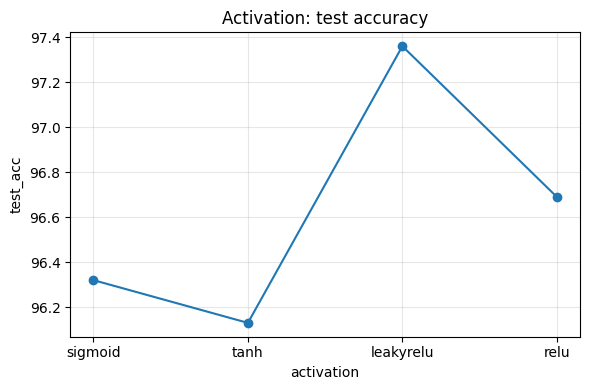

In [10]:
depth_values = [3, 5, 7]
depth_df, depth_histories = run_sweep("depth", depth_values, base_config)
depth_df = depth_df.sort_values("depth")
depth_df

plot_loss_curves(depth_histories, "Depth: train loss")
plot_metric(depth_df, "depth", "test_acc", "Depth: test accuracy")

hidden_values = [64, 128, 256, 512]
hidden_df, hidden_histories = run_sweep("hidden_size", hidden_values, base_config)
hidden_df = hidden_df.sort_values("hidden_size")
hidden_df

plot_loss_curves(hidden_histories, "Hidden size: train loss")
plot_metric(hidden_df, "hidden_size", "test_acc", "Hidden size: test accuracy")

activation_values = ["sigmoid", "tanh", "leakyrelu", "relu"]
activation_df, activation_histories = run_sweep("activation", activation_values, base_config)
activation_df

plot_loss_curves(activation_histories, "Activation: train loss")
plot_metric(activation_df, "activation", "test_acc", "Activation: test accuracy")

In [11]:
# 导入必要的库
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# 设置设备 - 检查是否有可用的GPU，如果有则使用GPU，否则使用CPU
# 这可以显著加速训练过程，因为GPU擅长并行计算
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用设备: {device}")  # 打印当前使用的设备信息

# 数据预处理和加载
# transforms.Compose 将多个数据转换操作组合在一起
transform = transforms.Compose([
    transforms.ToTensor(),  # 将PIL图像或numpy数组转换为PyTorch张量
    transforms.Normalize((0.1307,), (0.3081,))  # 使用MNIST数据集的均值和标准差进行标准化
    # 标准化公式: (input - mean) / std
])

# 加载MNIST数据集
# datasets.MNIST是PyTorch提供的MNIST数据集加载器
# root: 数据集存储路径
# train=True: 加载训练集
# download=True: 如果数据集不存在则自动下载
# transform: 应用上面定义的数据转换
train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST('./data', train=False, download=True, transform=transform)

# 创建数据加载器
# DataLoader负责批量加载数据，支持多进程数据加载和数据打乱
# batch_size=64: 每个批次包含64个样本
# shuffle=True: 在每个epoch开始时打乱训练数据顺序
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)  # 测试集不需要打乱

# 建立全连接神经网络模型
# nn.Sequential是一个顺序容器，模块将按照它们在构造函数中传递的顺序添加
model = nn.Sequential(
    nn.Flatten(),  # 将28x28的图像展平为784维的向量
    nn.Linear(784, 128),  # 全连接层，输入维度784，输出维度128
    nn.ReLU(),  # ReLU激活函数，引入非线性
    nn.Linear(128, 10)  # 输出层，输入维度128，输出维度10（对应10个数字类别）
).to(device)  # 将模型移动到指定的设备（GPU或CPU）

# 配置训练方法：优化器、损失函数
# optim.Adam是一种自适应学习率的优化算法，结合了AdaGrad和RMSProp的优点
optimizer = optim.Adam(model.parameters())  # 传入模型参数以便优化器知道要优化什么
# nn.CrossEntropyLoss是交叉熵损失函数，适用于多分类问题
# 它内部已经包含了Softmax操作，所以模型最后一层不需要添加Softmax
criterion = nn.CrossEntropyLoss()

# 训练模型
model.train()  # 将模型设置为训练模式，这会启用dropout和batch normalization等训练特定行为
for epoch in range(5):  # 训练5个epoch
    for data, target in train_loader:  # 遍历训练数据加载器中的每个批次
        data, target = data.to(device), target.to(device)  # 将数据移动到指定设备
        
        optimizer.zero_grad()  # 清除之前的梯度，防止梯度累积
        output = model(data)  # 前向传播，计算模型输出
        loss = criterion(output, target)  # 计算损失
        loss.backward()  # 反向传播，计算梯度
        optimizer.step()  # 更新模型参数
    
    print(f'Epoch {epoch+1} completed')  # 打印当前epoch完成信息

# 模型评估
model.eval()  # 将模型设置为评估模式，这会禁用dropout和batch normalization等训练特定行为
test_loss = 0  # 初始化测试损失
correct = 0  # 初始化正确预测的样本数
total = 0  # 初始化总样本数

with torch.no_grad():  # 禁用梯度计算，节省内存和计算资源
    for data, target in test_loader:  # 遍历测试数据加载器中的每个批次
        data, target = data.to(device), target.to(device)  # 将数据移动到指定设备
        output = model(data)  # 前向传播，计算模型输出
        test_loss += criterion(output, target).item()  # 累加批次损失
        pred = output.argmax(dim=1, keepdim=True)  # 获取预测结果（概率最大的类别）
        correct += pred.eq(target.view_as(pred)).sum().item()  # 统计正确预测的数量
        total += target.size(0)  # 累加样本数量

# 计算平均测试损失和准确率
test_loss /= len(test_loader)  # 平均损失 = 总损失 / 批次数量
accuracy = 100. * correct / total  # 准确率 = 正确预测数 / 总样本数 * 100%

# 打印测试结果
print(f'Test set: Average loss: {test_loss:.4f}, Accuracy: {correct}/{total} ({accuracy:.2f}%)')

使用设备: cpu
Epoch 1 completed
Epoch 2 completed
Epoch 3 completed
Epoch 4 completed
Epoch 5 completed
Test set: Average loss: 0.0749, Accuracy: 9772/10000 (97.72%)


使用设备: cpu
数据形状: x=(10000, 1), y=(10000, 1)
数据样例(前5行):
          x          y
0  1.095824  15.335912
1 -0.244486   1.767398
2  1.434392  47.293346
3  0.789472   5.505466
4 -1.623291  12.633568
数据样例(随机5行):
             x           y
6252 -0.282431    1.738137
4684  1.987638  221.152161
1731 -1.796477   19.346449
4742  1.116554   16.477379
4521 -0.344801    1.698796


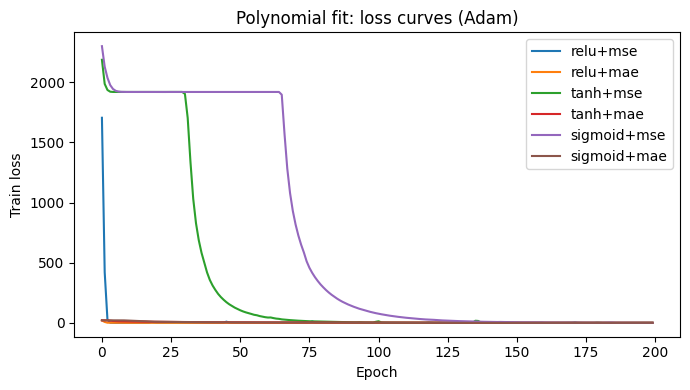

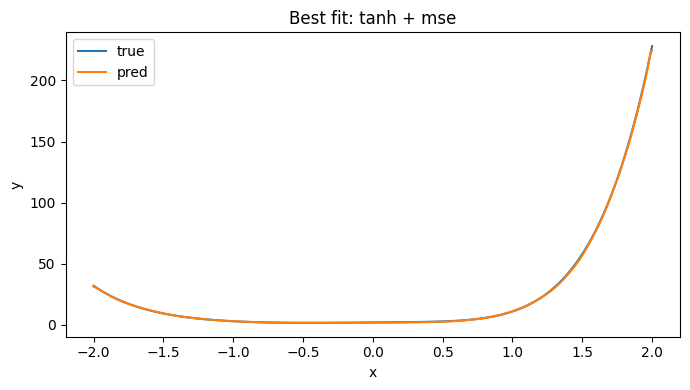

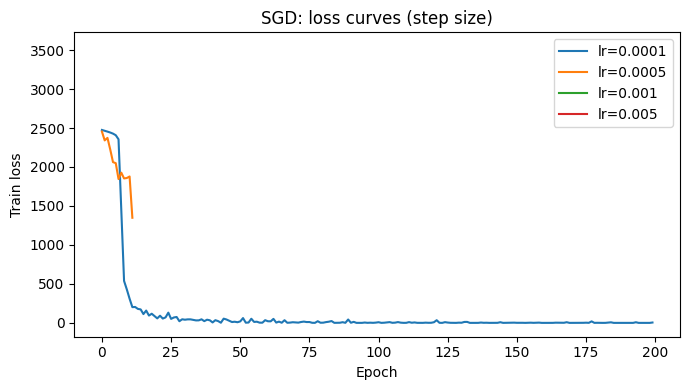

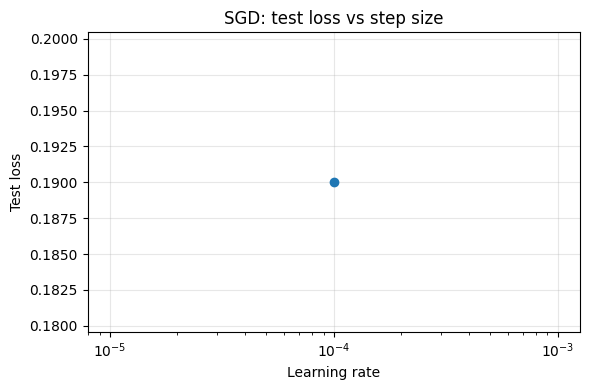

In [12]:
import numpy as np
import pandas as pd
import psutil
import time
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用设备: {device}")

POLY_EPOCHS = 200
POLY_BATCH_SIZE = 256
POLY_LR = 1e-3

def make_poly_data(n=10000, seed=42):
    rng = np.random.default_rng(seed)
    x = rng.uniform(-2, 2, size=(n, 1)).astype(np.float32)
    y = x**6 + 3 * x**5 + 4 * x**4 + x + 2
    return x, y

def poly_activation(name):
    name = name.lower()
    if name == "relu":
        return nn.ReLU
    if name == "tanh":
        return nn.Tanh
    if name == "sigmoid":
        return nn.Sigmoid
    if name == "leakyrelu":
        return nn.LeakyReLU
    raise ValueError(f"Unsupported activation: {name}")

def build_poly_mlp(hidden_size=200, depth=6, activation="relu"):
    act = poly_activation(activation)
    layers = [nn.Linear(1, hidden_size), act()]
    for _ in range(depth - 1):
        layers.extend([nn.Linear(hidden_size, hidden_size), act()])
    layers.append(nn.Linear(hidden_size, 1))
    return nn.Sequential(*layers).to(device)

def get_loss_fn(name):
    name = name.lower()
    if name == "mse":
        return nn.MSELoss()
    if name == "mae":
        return nn.L1Loss()
    if name == "huber":
        return nn.SmoothL1Loss()
    raise ValueError(f"Unsupported loss: {name}")

def make_optimizer(model, name, lr):
    name = name.lower()
    if name == "adam":
        return optim.Adam(model.parameters(), lr=lr)
    if name == "sgd":
        return optim.SGD(model.parameters(), lr=lr)
    raise ValueError(f"Unsupported optimizer: {name}")

def train_poly_model(
    model,
    train_loader,
    loss_name="mse",
    optimizer_name="adam",
    lr=POLY_LR,
    epochs=POLY_EPOCHS,
    ):
    optimizer = make_optimizer(model, optimizer_name, lr)
    loss_fn = get_loss_fn(loss_name)
    history = []

    process = psutil.Process()
    mem_before = process.memory_info().rss
    if device.type == "cuda":
        torch.cuda.reset_peak_memory_stats()

    start = time.perf_counter()
    for _ in range(epochs):
        model.train()
        running_loss = 0.0
        seen = 0
        for x_batch, y_batch in train_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()
            pred = model(x_batch)
            loss = loss_fn(pred, y_batch)
            loss.backward()
            optimizer.step()

            batch_size = x_batch.size(0)
            running_loss += loss.item() * batch_size
            seen += batch_size

        history.append(running_loss / max(seen, 1))

    elapsed = time.perf_counter() - start
    mem_after = process.memory_info().rss
    gpu_peak = torch.cuda.max_memory_allocated() if device.type == "cuda" else 0

    stats = {
        "train_time_sec": elapsed,
        "cpu_mem_delta_mb": (mem_after - mem_before) / (1024 ** 2),
        "gpu_peak_mb": gpu_peak / (1024 ** 2),
        "optimizer": optimizer_name,
        "lr": lr,
    }
    return history, stats

def eval_poly_model(model, data_loader, loss_name="mse"):
    loss_fn = get_loss_fn(loss_name)
    model.eval()
    running_loss = 0.0
    seen = 0
    with torch.no_grad():
        for x_batch, y_batch in data_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            pred = model(x_batch)
            loss = loss_fn(pred, y_batch)

            batch_size = x_batch.size(0)
            running_loss += loss.item() * batch_size
            seen += batch_size
    return running_loss / max(seen, 1)

x, y = make_poly_data()
print(f"数据形状: x={x.shape}, y={y.shape}")
sample_df = pd.DataFrame({"x": x.squeeze(), "y": y.squeeze()})
print("数据样例(前5行):")
print(sample_df.head(5))
print("数据样例(随机5行):")
print(sample_df.sample(5, random_state=42))

split = int(0.8 * len(x))
x_train, y_train = x[:split], y[:split]
x_test, y_test = x[split:], y[split:]

train_ds = torch.utils.data.TensorDataset(
    torch.from_numpy(x_train), torch.from_numpy(y_train)
)
test_ds = torch.utils.data.TensorDataset(
    torch.from_numpy(x_test), torch.from_numpy(y_test)
)

train_loader = DataLoader(train_ds, batch_size=POLY_BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=POLY_BATCH_SIZE, shuffle=False)

poly_activations = ["relu", "tanh", "sigmoid"]
poly_losses = ["mse", "mae"]

poly_results = []
poly_histories = {}
poly_models = {}

for act in poly_activations:
    for loss_name in poly_losses:
        model = build_poly_mlp(hidden_size=200, depth=6, activation=act)
        history, stats = train_poly_model(
            model,
            train_loader,
            loss_name=loss_name,
            optimizer_name="adam",
            lr=POLY_LR,
        )
        test_loss = eval_poly_model(model, test_loader, loss_name=loss_name)
        stats.update(
            {
                "activation": act,
                "loss": loss_name,
                "final_train_loss": history[-1],
                "test_loss": test_loss,
            }
        )
        poly_results.append(stats)
        poly_histories[(act, loss_name)] = history
        poly_models[(act, loss_name)] = model

poly_df = pd.DataFrame(poly_results).sort_values("test_loss")
poly_df

plt.figure(figsize=(7, 4))
for key, history in poly_histories.items():
    label = f"{key[0]}+{key[1]}"
    plt.plot(history, label=label)
plt.title("Polynomial fit: loss curves (Adam)")
plt.xlabel("Epoch")
plt.ylabel("Train loss")
plt.legend()
plt.tight_layout()

best_row = poly_df.iloc[0]
best_key = (best_row["activation"], best_row["loss"])
best_model = poly_models[best_key]
best_model.eval()

x_plot = np.linspace(-2, 2, 400, dtype=np.float32).reshape(-1, 1)
with torch.no_grad():
    pred = best_model(torch.from_numpy(x_plot).to(device)).cpu().numpy()

y_true = x_plot**6 + 3 * x_plot**5 + 4 * x_plot**4 + x_plot + 2

plt.figure(figsize=(7, 4))
plt.plot(x_plot, y_true, label="true")
plt.plot(x_plot, pred, label="pred")
plt.title(f"Best fit: {best_key[0]} + {best_key[1]}")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.tight_layout()

sgd_lrs = [1e-4, 5e-4, 1e-3, 5e-3]
sgd_results = []
sgd_histories = {}

for lr in sgd_lrs:
    model = build_poly_mlp(hidden_size=200, depth=6, activation="relu")
    history, stats = train_poly_model(
        model,
        train_loader,
        loss_name="mse",
        optimizer_name="sgd",
        lr=lr,
    )
    test_loss = eval_poly_model(model, test_loader, loss_name="mse")
    stats.update(
        {
            "activation": "relu",
            "loss": "mse",
            "final_train_loss": history[-1],
            "test_loss": test_loss,
        }
    )
    sgd_results.append(stats)
    sgd_histories[lr] = history

sgd_df = pd.DataFrame(sgd_results).sort_values("lr")
sgd_df

plt.figure(figsize=(7, 4))
for lr in sorted(sgd_histories):
    plt.plot(sgd_histories[lr], label=f"lr={lr}")
plt.title("SGD: loss curves (step size)")
plt.xlabel("Epoch")
plt.ylabel("Train loss")
plt.legend()
plt.tight_layout()

plt.figure(figsize=(6, 4))
plt.plot(sgd_df["lr"], sgd_df["test_loss"], marker="o")
plt.xscale("log")
plt.title("SGD: test loss vs step size")
plt.xlabel("Learning rate")
plt.ylabel("Test loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()

## 任务三结果与结论

- 数据样例截图：
- 激活函数/损失函数对比结果截图：
- SGD学习率(步长)对比损失曲线截图：
- 内存/显存/时间统计表截图：

结论（运行后填写）：
1. 
2. 

调参记录（运行后填写）：
- 激活函数：
- 损失函数：
- 优化器/学习率：